In [1]:
import pandas as pd
import numpy as np
import requests
from pathlib import Path

PROJECT_DIR = Path("..").resolve()
RAW_DIR = PROJECT_DIR / "data" / "raw"
BIKESHARE_SRC = PROJECT_DIR / "toronto-bikeshare-ridership-2025"  # source monthly CSVs

RAW_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project dir: {PROJECT_DIR}")
print(f"Raw data dir: {RAW_DIR}")
print(f"Source CSVs: {BIKESHARE_SRC}")

Project dir: C:\Users\abdul\Documents\Toronto Bikeshare Forecasting
Raw data dir: C:\Users\abdul\Documents\Toronto Bikeshare Forecasting\data\raw
Source CSVs: C:\Users\abdul\Documents\Toronto Bikeshare Forecasting\toronto-bikeshare-ridership-2025


Load all monthly CSVs (Jan to Oct 2025), concat them, and do a quick sanity check.

In [ ]:
csv_files = sorted(BIKESHARE_SRC.glob("bikeshare_2025_*.csv"))  # load all monthly CSVs
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    df = pd.read_csv(f, parse_dates=["Start_Time", "End_Time"], encoding="latin-1")
    print(f"  {f.name}: {len(df):,} rows")
    dfs.append(df)

rides = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rides: {len(rides):,}")
print(f"Date range: {rides['Start_Time'].min()} to {rides['Start_Time'].max()}")
rides.head() # preview start of the combined DataFrame

Found 10 CSV files
  bikeshare_2025_01.csv: 202,946 rows
  bikeshare_2025_02.csv: 125,670 rows
  bikeshare_2025_03.csv: 312,178 rows
  bikeshare_2025_04.csv: 471,525 rows
  bikeshare_2025_05.csv: 699,461 rows
  bikeshare_2025_06.csv: 980,624 rows
  bikeshare_2025_07.csv: 1,192,062 rows
  bikeshare_2025_08.csv: 1,164,697 rows
  bikeshare_2025_09.csv: 1,062,001 rows
  bikeshare_2025_10.csv: 872,482 rows

Total rides: 7,083,646
Date range: 2025-01-01 00:01:51 to 2025-10-31 23:59:59


,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Bike_Model
0,34637659,193,7192.0,2025-01-01 00:02:15,Harbord St / Clinton St,7155.0,2025-01-01 00:05:28,Harbord St / Clinton St,4422,Member,ICONIC
1,34637678,464,7508.0,2025-01-01 00:14:07,Berkeley St / Dundas St E - SMART,7042.0,2025-01-01 00:21:51,Berkeley St / Dundas St E - SMART,4618,Member,ICONIC
2,34637663,770,7094.0,2025-01-01 00:07:21,14 Arundel Ave,7777.0,2025-01-01 00:20:11,14 Arundel Ave,7975,Member,EFIT G5
3,34637679,559,7032.0,2025-01-01 00:14:09,Augusta Ave / Dundas St W,7541.0,2025-01-01 00:23:28,Augusta Ave / Dundas St W,3179,Member,ICONIC
4,34637658,116,7017.0,2025-01-01 00:02:13,Widmer St / Adelaide St W - SMART,7102.0,2025-01-01 00:04:09,Widmer St / Adelaide St W - SMART,3177,Member,ICONIC


In [3]:
print("Columns:", rides.columns.tolist())  # quick data overview
print(f"\nNull counts:\n{rides.isnull().sum()}")
print(f"\nUser types: {rides['User_Type'].value_counts().to_dict()}")
print(f"Unique stations (start): {rides['Start_Station_Id'].nunique()}")
print(f"Dtypes:\n{rides.dtypes}")

Columns: ['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']

Null counts:
Trip_Id                  0
Trip_Duration            0
Start_Station_Id         7
Start_Time               0
Start_Station_Name       7
End_Station_Id        5844
End_Time               944
End_Station_Name         7
Bike_Id                  0
User_Type                0
Bike_Model               0
dtype: int64

User types: {'Member': 5054784, 'Casual': 2028862}
Unique stations (start): 1031
Dtypes:
Trip_Id                        int64
Trip_Duration                  int64
Start_Station_Id             float64
Start_Time            datetime64[ns]
Start_Station_Name            object
End_Station_Id               float64
End_Time              datetime64[ns]
End_Station_Name              object
Bike_Id                        int64
User_Type                     object
Bike_Model                    obje

Fetching station metadata by Pull station info (capacity, lat/lon) from the Toronto Open Data CKAN API. Need coordinates for clustering and capacity as a feature.

In [4]:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"

url = base_url + "/api/3/action/package_show"  # get package metadata for bike-share-toronto
params = {"id": "bike-share-toronto"}
package = requests.get(url, params=params, timeout=30).json()

for idx, resource in enumerate(package["result"]["resources"]):  # list all resources
    print(f"[{idx}] {resource['name']}, format: {resource.get('format', 'N/A')}, datastore_active: {resource.get('datastore_active', False)}")
    print(f"     id: {resource['id']}")
    print()

[0] bike-share-json, format: JSON, datastore_active: False
     id: 5c1c2c06-d27f-47b7-ae82-926a6d23d76f

[1] bike-share-gbfs-general-bikeshare-feed-specification, format: JSON, datastore_active: False
     id: b69873a1-c180-4ccd-a970-514e434b4971

[2] gbfs-documentation, format: WEB, datastore_active: False
     id: 2eb37596-96a7-4379-b334-a47a396e9ac3

[3] bike-share-stations-readme, format: TXT, datastore_active: False
     id: 5ee32dcb-3f4d-4dfe-a3ad-e27f2c13b5a3



In [5]:
gbfs_resource = package["result"]["resources"][1]  # bike-share-gbfs
print(f"Using resource: {gbfs_resource['name']}")

gbfs_url = gbfs_resource["url"]  # get the GBFS index URL
print(f"GBFS index URL: {gbfs_url}")
gbfs_resp = requests.get(gbfs_url, timeout=30)
gbfs_resp.raise_for_status()
gbfs_index = gbfs_resp.json()

feeds = gbfs_index["data"]["en"]["feeds"]
for feed in feeds:
    print(f"  Feed: {feed['name']} - {feed['url']}")

station_info_url = next(f["url"] for f in feeds if f["name"] == "station_information")  # find station_information feed
print(f"\nFetching station info from: {station_info_url}")

station_resp = requests.get(station_info_url, timeout=30)  # fetch station information
station_resp.raise_for_status()
station_json = station_resp.json()

stations = pd.DataFrame(station_json["data"]["stations"])
print(f"\nFetched {len(stations)} stations")
print(f"Columns: {stations.columns.tolist()}")
stations.head()

Using resource: bike-share-gbfs-general-bikeshare-feed-specification
GBFS index URL: https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/2b44db0d-eea9-442d-b038-79335368ad5a/resource/b69873a1-c180-4ccd-a970-514e434b4971/download/bike-share-gbfs-general-bikeshare-feed-specification.json
  Feed: system regions - https://tor.publicbikesystem.net/ube/gbfs/v1/en/system_regions
  Feed: system_information - https://tor.publicbikesystem.net/ube/gbfs/v1/en/system_information
  Feed: station_information - https://tor.publicbikesystem.net/ube/gbfs/v1/en/station_information
  Feed: station_status - https://tor.publicbikesystem.net/ube/gbfs/v1/en/station_status
  Feed: system_pricing_plans - https://tor.publicbikesystem.net/ube/gbfs/v1/en/system_pricing_plans

Fetching station info from: https://tor.publicbikesystem.net/ube/gbfs/v1/en/station_information

Fetched 1022 stations
Columns: ['station_id', 'external_id', 'name', 'physical_configuration', 'lat', 'lon', 'altitude', 'address', 'capacity

,station_id,external_id,name,physical_configuration,lat,lon,altitude,address,capacity,is_charging_station,rental_methods,groups,obcn,short_name,nearby_distance,_ride_code_support,rental_uris,post_code,is_valet_station,cross_street
0,7000,f8aa7900-e9c7-11ef-984e-124c66246c7d,Fort York Blvd / Capreol Ct,REGULAR,43.639832,-79.395954,NaN,Fort York Blvd / Capreol Ct,47,False,"[key, transitcard, creditcard, phone]","[South, Fort York - Entertainment District]",647-643-9607,647-643-9607,500.0,True,{},NaN,NaN,NaN
1,7001,f8aaeb6e-e9c7-11ef-984e-124c66246c7d,Wellesley Station Green P,ELECTRICBIKESTATION,43.664964,-79.383550,NaN,Yonge / Wellesley,23,True,"[key, transitcard, creditcard, phone]","[E-Charging , South, Church Wellesley / Yorkvi...",416-617-9576,416-617-9576,500.0,True,{},M4Y 1G7,NaN,NaN
2,7002,f8aaef03-e9c7-11ef-984e-124c66246c7d,St. George St / Bloor St W,REGULAR,43.667131,-79.399555,NaN,St. George St / Bloor St W,19,False,"[key, transitcard, creditcard, phone]","[South, U of T - Hospital Row]",647-643-9615,647-643-9615,500.0,True,{},NaN,NaN,NaN
3,7003,f8ab20ac-e9c7-11ef-984e-124c66246c7d,Madison Ave / Bloor St W,REGULAR,43.667018,-79.402796,NaN,Madison Ave / Bloor St W,15,False,"[key, transitcard, creditcard, phone]","[South, Bloor St W / Annex]",647-631-4587,647-631-4587,500.0,True,{},NaN,NaN,NaN
4,7005,f8ab51f8-e9c7-11ef-984e-124c66246c7d,King St W / York St,VAULT,43.648001,-79.383177,0.0,King St W / York St,23,False,"[key, transitcard, phone]","[South, Financial District]",647-643-9693,647-643-9693,500.0,True,{},NaN,NaN,NaN


In [6]:
print(f"Available columns: {stations.columns.tolist()}")

stations["station_id"] = pd.to_numeric(stations["station_id"], errors="coerce").astype("Int64")
stations = stations.dropna(subset=["station_id"])
stations = stations[["station_id", "name", "lat", "lon", "capacity"]].copy()  # just keep what we need

print(f"\nStations after cleanup: {len(stations)}")
print(f"Capacity range: {stations['capacity'].min()} to {stations['capacity'].max()}")

ride_station_ids = set(rides["Start_Station_Id"].dropna().astype(int).unique())  # check coverage against ridership
meta_station_ids = set(stations["station_id"].dropna().unique())
print(f"\nRidership station IDs: {len(ride_station_ids)}")
print(f"Metadata station IDs: {len(meta_station_ids)}")
print(f"Matched: {len(ride_station_ids & meta_station_ids)}")
print(f"In rides but not metadata: {len(ride_station_ids - meta_station_ids)}")
stations.head()

Available columns: ['station_id', 'external_id', 'name', 'physical_configuration', 'lat', 'lon', 'altitude', 'address', 'capacity', 'is_charging_station', 'rental_methods', 'groups', 'obcn', 'short_name', 'nearby_distance', '_ride_code_support', 'rental_uris', 'post_code', 'is_valet_station', 'cross_street']

Stations after cleanup: 1022
Capacity range: 4 to 79

Ridership station IDs: 1031
Metadata station IDs: 1022
Matched: 979
In rides but not metadata: 52


,station_id,name,lat,lon,capacity
0,7000,Fort York Blvd / Capreol Ct,43.639832,-79.395954,47
1,7001,Wellesley Station Green P,43.664964,-79.383550,23
2,7002,St. George St / Bloor St W,43.667131,-79.399555,19
3,7003,Madison Ave / Bloor St W,43.667018,-79.402796,15
4,7005,King St W / York St,43.648001,-79.383177,23


Get weather hourly weather for Toronto (Jan 1 to Oct 31, 2025) from the Open-Meteo Archive API (free, no key needed getting weather fields).

In [7]:
WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"  # Open-Meteo Archive API

weather_params = {
    "latitude": 43.65,
    "longitude": -79.38,
    "start_date": "2025-01-01",
    "end_date": "2025-10-31",
    "hourly": "temperature_2m,precipitation,wind_speed_10m,weather_code",
    "timezone": "America/Toronto"
}

resp = requests.get(WEATHER_URL, params=weather_params, timeout=60)
resp.raise_for_status()
weather_json = resp.json()

weather = pd.DataFrame({
    "datetime": pd.to_datetime(weather_json["hourly"]["time"]),
    "temperature_c": weather_json["hourly"]["temperature_2m"],
    "precipitation_mm": weather_json["hourly"]["precipitation"],
    "wind_speed_kmh": weather_json["hourly"]["wind_speed_10m"],
    "weather_code": weather_json["hourly"]["weather_code"]
})

print(f"Weather records: {len(weather):,}")
print(f"Date range: {weather['datetime'].min()} to {weather['datetime'].max()}")
print(f"\nNull counts:\n{weather.isnull().sum()}")
print(f"\nTemperature range: {weather['temperature_c'].min():.1f} to {weather['temperature_c'].max():.1f} C")
weather.head()

Weather records: 7,296
Date range: 2025-01-01 00:00:00 to 2025-10-31 23:00:00

Null counts:
datetime            0
temperature_c       0
precipitation_mm    0
wind_speed_kmh      0
weather_code        0
dtype: int64

Temperature range: -20.1 to 35.8 C


,datetime,temperature_c,precipitation_mm,wind_speed_kmh,weather_code
0,2025-01-01 00:00:00,3.7,0.0,14.9,3
1,2025-01-01 01:00:00,3.3,0.0,14.0,3
2,2025-01-01 02:00:00,2.8,0.0,15.2,3
3,2025-01-01 03:00:00,2.2,0.0,17.9,3
4,2025-01-01 04:00:00,2.0,0.0,19.6,3


In [8]:
rides.to_csv(RAW_DIR / "rides_raw.csv", index=False)
stations.to_csv(RAW_DIR / "stations.csv", index=False)
weather.to_csv(RAW_DIR / "weather_hourly.csv", index=False)

print("Saved to data/raw/:")
for f in sorted(RAW_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}, {size_mb:.1f} MB")

Saved to data/raw/:
  rides_raw.csv, 999.7 MB
  stations.csv, 0.1 MB
  weather_hourly.csv, 0.3 MB


## Forecast-Focused EDA on Processed Data

This section runs exploratory analysis for hourly pickup forecasting using the processed train/test files.
It focuses on temporal patterns, weather effects, data quality checks, and feature sanity checks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)

def find_processed_dir(start: Path) -> Path:
    for base in [start, *start.parents]:
        candidates = [base / "processed", base / "data" / "processed"]
        for candidate in candidates:
            if candidate.exists():
                return candidate
    raise FileNotFoundError("Could not find a processed data directory from the current notebook path.")

PROCESSED_DIR = find_processed_dir(Path.cwd())
train_path = PROCESSED_DIR / "train.csv"
test_path = PROCESSED_DIR / "test.csv"

train = pd.read_csv(train_path, parse_dates=["hour"])
test = pd.read_csv(test_path, parse_dates=["hour"])
full = pd.concat([
    train.assign(split="train"),
    test.assign(split="test")
], ignore_index=True)

print(f"Processed dir: {PROCESSED_DIR}")
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Full shape:  {full.shape}")
full.head()

Processed dir: c:\Users\serverpc\Desktop\School Github Projects\ML Proj\processed
Train shape: (72000, 21)
Test shape:  (37440, 21)
Full shape:  (109440, 22)


,cluster_id,hour,pickups,temperature_c,precipitation_mm,wind_speed_kmh,weather_code,cluster_capacity,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_holiday,is_rainy,lag_1h,lag_24h,lag_168h,rolling_24h_mean,rolling_168h_mean,cluster_avg_pickups,split
0,0,2025-01-01 00:00:00,26,3.7,0.0,14.9,3,2032,0,2,1,0,0,1,0,0.0,0.0,0.0,0.000000,0.000000,113.857083,train
1,0,2025-01-01 01:00:00,12,3.3,0.0,14.0,3,2032,1,2,1,0,0,1,0,26.0,0.0,0.0,26.000000,26.000000,113.857083,train
2,0,2025-01-01 02:00:00,9,2.8,0.0,15.2,3,2032,2,2,1,0,0,1,0,12.0,0.0,0.0,19.000000,19.000000,113.857083,train
3,0,2025-01-01 03:00:00,21,2.2,0.0,17.9,3,2032,3,2,1,0,0,1,0,9.0,0.0,0.0,15.666667,15.666667,113.857083,train
4,0,2025-01-01 04:00:00,5,2.0,0.0,19.6,3,2032,4,2,1,0,0,1,0,21.0,0.0,0.0,17.000000,17.000000,113.857083,train


In [3]:
# Core data quality checks
required_cols = ["cluster_id", "hour", "pickups"]
missing_required = [c for c in required_cols if c not in full.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

missing_summary = full.isna().sum().sort_values(ascending=False)
dup_count = full.duplicated(subset=["cluster_id", "hour"]).sum()
negative_pickups = (full["pickups"] < 0).sum()
negative_precip = (full["precipitation_mm"] < 0).sum() if "precipitation_mm" in full.columns else np.nan

full_sorted = full.sort_values(["cluster_id", "hour"]).copy()
step = full_sorted.groupby("cluster_id")["hour"].diff()
gap_count = (step.dropna() != pd.Timedelta(hours=1)).sum()

print("Missing values (top 15):")
display(missing_summary.head(15).to_frame("missing_count"))
print(f"Duplicate rows by cluster_id + hour: {dup_count}")
print(f"Negative pickups: {negative_pickups}")
print(f"Negative precipitation rows: {negative_precip}")
print(f"Non-hourly time gaps across clusters: {gap_count}")

Missing values (top 15):


,missing_count
cluster_id,0
hour,0
pickups,0
temperature_c,0
precipitation_mm,0
wind_speed_kmh,0
weather_code,0
cluster_capacity,0
hour_of_day,0
day_of_week,0


Duplicate rows by cluster_id + hour: 0
Negative pickups: 0
Negative precipitation rows: 0
Non-hourly time gaps across clusters: 0


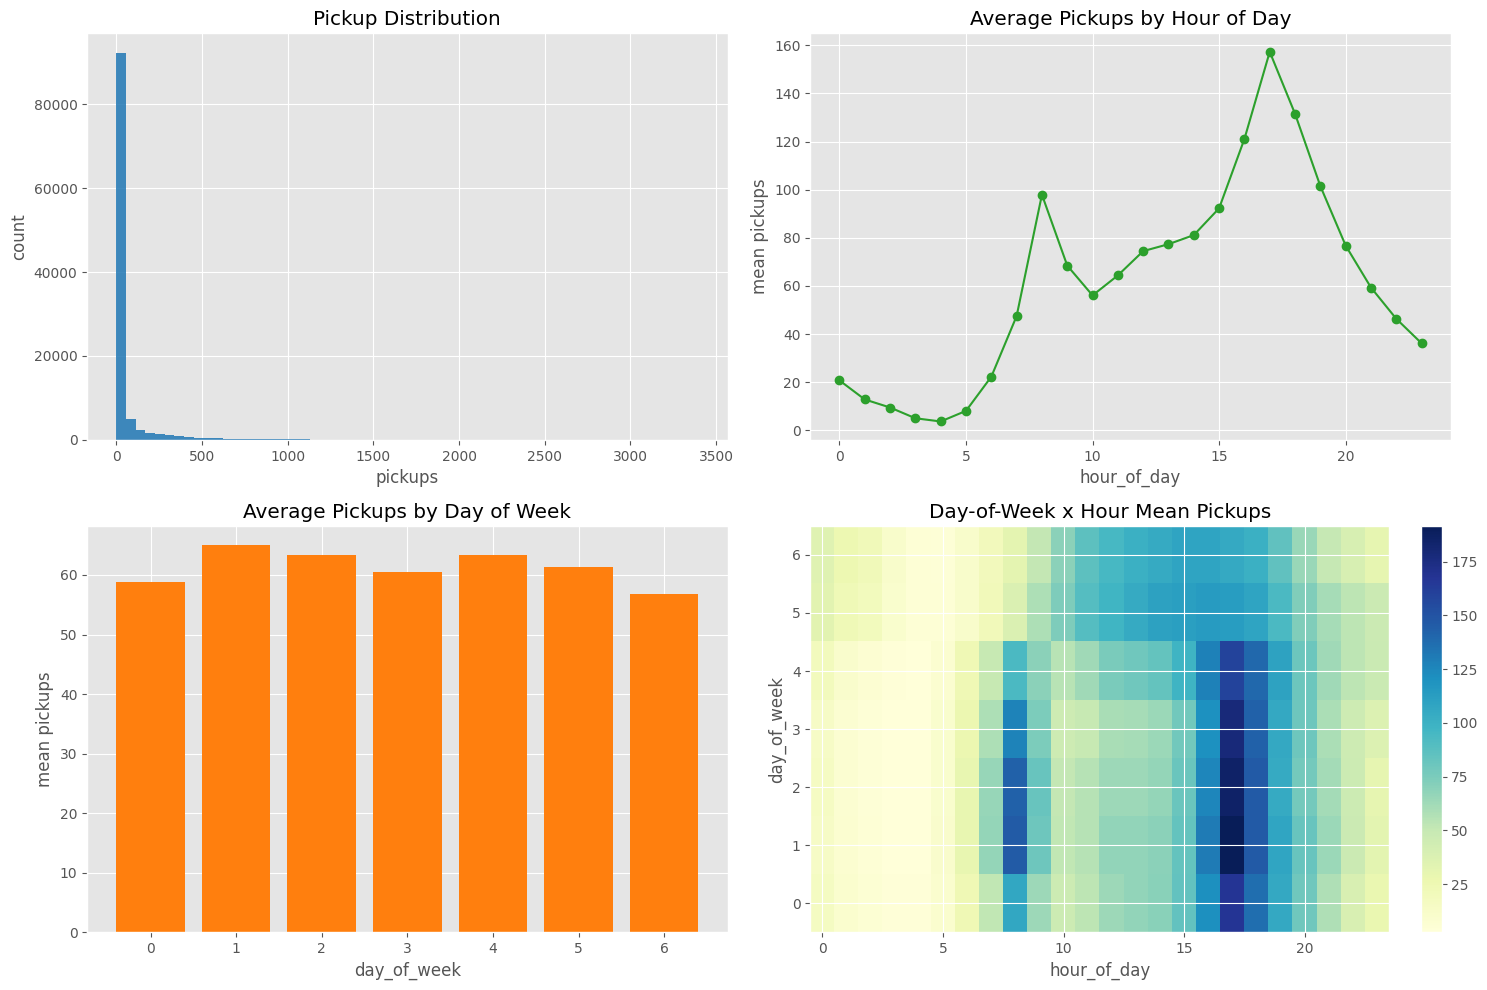

In [4]:
# Temporal demand patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(full["pickups"].dropna(), bins=60, color="#1f77b4", alpha=0.85)
axes[0, 0].set_title("Pickup Distribution")
axes[0, 0].set_xlabel("pickups")
axes[0, 0].set_ylabel("count")

hourly_profile = full.groupby("hour_of_day", as_index=False)["pickups"].mean()
axes[0, 1].plot(hourly_profile["hour_of_day"], hourly_profile["pickups"], marker="o", color="#2ca02c")
axes[0, 1].set_title("Average Pickups by Hour of Day")
axes[0, 1].set_xlabel("hour_of_day")
axes[0, 1].set_ylabel("mean pickups")

dow_profile = full.groupby("day_of_week", as_index=False)["pickups"].mean()
axes[1, 0].bar(dow_profile["day_of_week"], dow_profile["pickups"], color="#ff7f0e")
axes[1, 0].set_title("Average Pickups by Day of Week")
axes[1, 0].set_xlabel("day_of_week")
axes[1, 0].set_ylabel("mean pickups")

pivot = full.pivot_table(index="day_of_week", columns="hour_of_day", values="pickups", aggfunc="mean")
im = axes[1, 1].imshow(pivot.values, aspect="auto", cmap="YlGnBu", origin="lower")
axes[1, 1].set_title("Day-of-Week x Hour Mean Pickups")
axes[1, 1].set_xlabel("hour_of_day")
axes[1, 1].set_ylabel("day_of_week")
fig.colorbar(im, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.show()

Available weather columns: ['temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_rainy']


C:\Users\serverpc\AppData\Local\Temp\ipykernel_26132\3247865946.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(box_data, labels=[str(int(c)) for c in top_codes], showfliers=False)


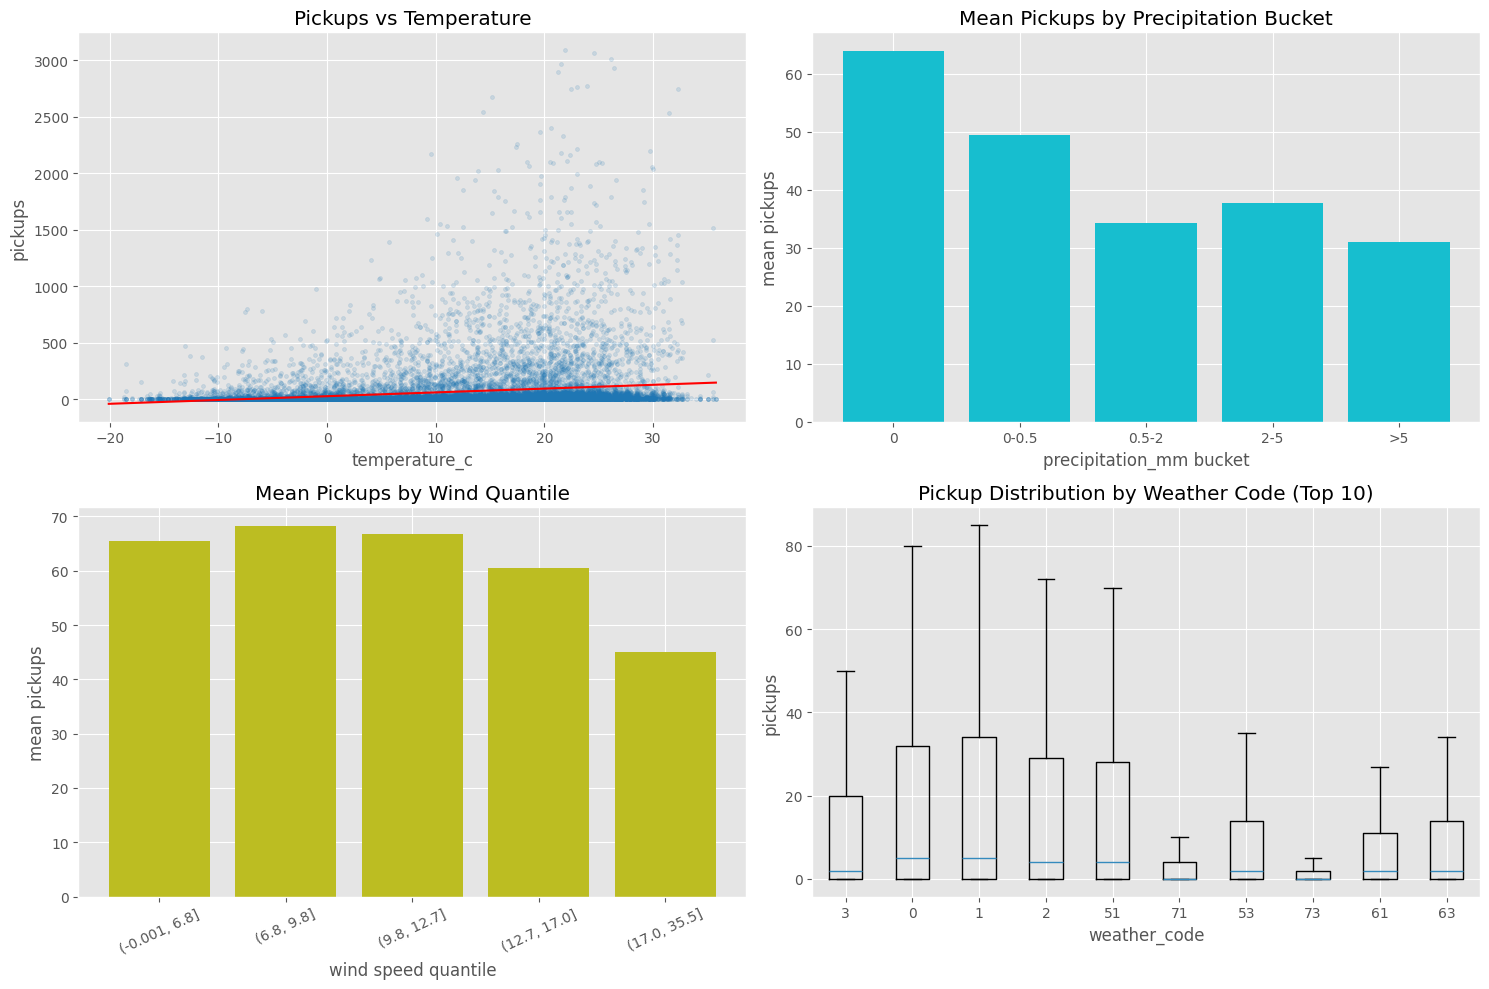

In [ ]:
# Weather relationship EDA
weather_cols = [c for c in ["temperature_c", "precipitation_mm", "wind_speed_kmh", "weather_code", "is_rainy"] if c in full.columns]
print("Available weather columns:", weather_cols)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

if "temperature_c" in full.columns:
    sample_df = full.sample(min(20000, len(full)), random_state=42)
    axes[0, 0].scatter(sample_df["temperature_c"], sample_df["pickups"], s=8, alpha=0.15, color="#1f77b4")
    z = np.polyfit(sample_df["temperature_c"], sample_df["pickups"], 1)
    p = np.poly1d(z)
    xs = np.linspace(sample_df["temperature_c"].min(), sample_df["temperature_c"].max(), 100)
    axes[0, 0].plot(xs, p(xs), color="red")
    axes[0, 0].set_title("Pickups vs Temperature")
    axes[0, 0].set_xlabel("temperature_c")
    axes[0, 0].set_ylabel("pickups")
else:
    axes[0, 0].set_visible(False)

if "precipitation_mm" in full.columns:
    precip_bin = pd.cut(full["precipitation_mm"], bins=[-0.001, 0, 0.5, 2, 5, 100], labels=["0", "0-0.5", "0.5-2", "2-5", ">5"])
    precip_profile = full.groupby(precip_bin, observed=True)["pickups"].mean().reset_index()
    axes[0, 1].bar(precip_profile["precipitation_mm"].astype(str), precip_profile["pickups"], color="#17becf")
    axes[0, 1].set_title("Mean Pickups by Precipitation Bucket")
    axes[0, 1].set_xlabel("precipitation_mm bucket")
    axes[0, 1].set_ylabel("mean pickups")
else:
    axes[0, 1].set_visible(False)

if "wind_speed_kmh" in full.columns:
    wind_bin = pd.qcut(full["wind_speed_kmh"], q=5, duplicates="drop")
    wind_profile = full.groupby(wind_bin, observed=True)["pickups"].mean().reset_index()
    axes[1, 0].bar(wind_profile["wind_speed_kmh"].astype(str), wind_profile["pickups"], color="#bcbd22")
    axes[1, 0].tick_params(axis="x", rotation=25)
    axes[1, 0].set_title("Mean Pickups by Wind Quantile")
    axes[1, 0].set_xlabel("wind speed quantile")
    axes[1, 0].set_ylabel("mean pickups")
else:
    axes[1, 0].set_visible(False)

if "weather_code" in full.columns:
    top_codes = full["weather_code"].value_counts().head(10).index
    box_data = [full.loc[full["weather_code"] == code, "pickups"].dropna() for code in top_codes]
    axes[1, 1].boxplot(box_data, tick_labels=[str(int(c)) for c in top_codes], showfliers=False)
    axes[1, 1].set_title("Pickup Distribution by Weather Code (Top 10)")
    axes[1, 1].set_xlabel("weather_code")
    axes[1, 1].set_ylabel("pickups")
else:
    axes[1, 1].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
# Lag and rolling feature sanity checks
feature_cols = [
    "pickups", "lag_1h", "lag_24h", "lag_168h",
    "rolling_24h_mean", "rolling_168h_mean", "cluster_avg_pickups"
]
feature_cols = [c for c in feature_cols if c in full.columns]

corr_series = full[feature_cols].corr(numeric_only=True)["pickups"].sort_values(ascending=False)
print("Correlation with pickups:")
display(corr_series.to_frame("corr_with_pickups"))

if "lag_1h" in full.columns:
    sorted_df = full.sort_values(["cluster_id", "hour"]).copy()
    recomputed_lag = sorted_df.groupby("cluster_id")["pickups"].shift(1)
    stored_lag = sorted_df["lag_1h"]
    bad_lag_rows = (recomputed_lag.fillna(-1) != stored_lag.fillna(-1)).sum()
    print(f"Potential lag_1h mismatches: {int(bad_lag_rows)}")

if "rolling_24h_mean" in full.columns:
    print("Rolling 24h mean summary:")
    display(full["rolling_24h_mean"].describe().to_frame("rolling_24h_mean"))

Correlation with pickups:


,corr_with_pickups
pickups,1.000000
lag_168h,0.956271
lag_24h,0.941334
lag_1h,0.935193
rolling_24h_mean,0.766800
rolling_168h_mean,0.763568
cluster_avg_pickups,0.668702


Potential lag_1h mismatches: 15
Rolling 24h mean summary:


,rolling_24h_mean
count,109440.000000
mean,61.200589
std,154.441519
min,0.000000
25%,0.958333
50%,4.916667
75%,30.166667
max,956.000000


Top clusters by average pickups:


,cluster_id,total_pickups,mean_pickups,std_pickups,avg_capacity,pickups_per_capacity,cv_pickups
14,14,3846488,527.205044,530.623273,5629.0,0.093659,1.006484
7,7,1284691,176.081552,177.148368,2688.0,0.065507,1.006059
0,0,828059,113.494929,121.888722,2032.0,0.055854,1.073957
2,2,214047,29.337582,35.970926,1498.0,0.019585,1.226104
6,6,137482,18.843476,21.751356,1084.0,0.017383,1.154318
4,4,129994,17.817160,21.072245,1022.0,0.017434,1.182694
8,8,97680,13.388158,13.936460,976.0,0.013717,1.040954
12,12,76256,10.451754,14.790560,745.0,0.014029,1.415127
10,10,27606,3.783717,5.354477,619.0,0.006113,1.415137
13,13,20203,2.769052,4.531148,483.0,0.005733,1.636354


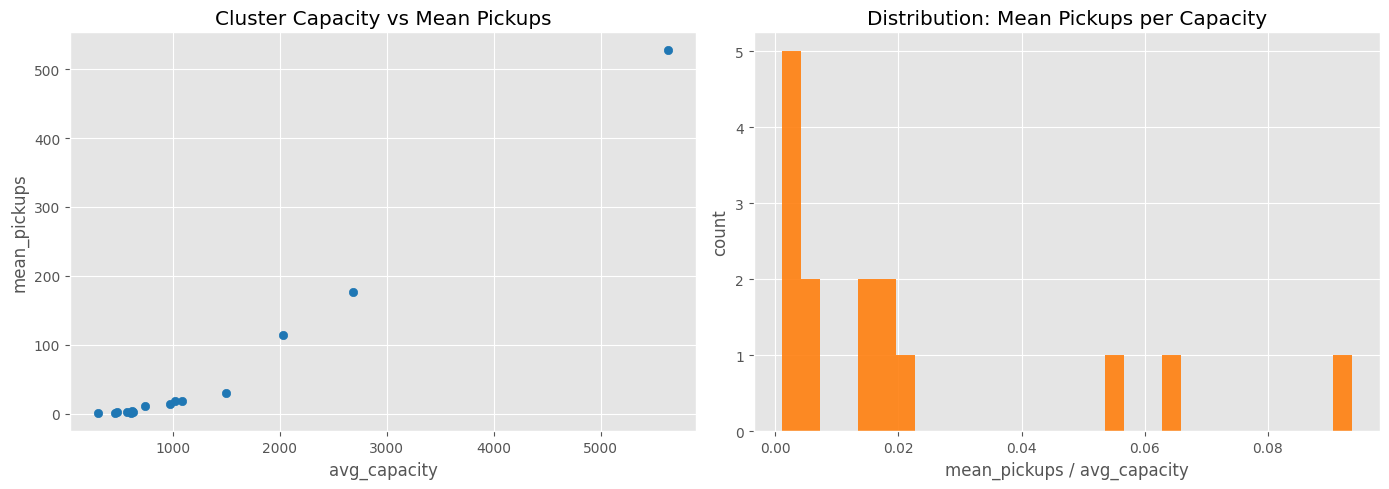

In [7]:
# Cluster-level behavior and capacity normalization
cluster_agg = full.groupby("cluster_id", as_index=False).agg(
    total_pickups=("pickups", "sum"),
    mean_pickups=("pickups", "mean"),
    std_pickups=("pickups", "std"),
    avg_capacity=("cluster_capacity", "mean")
)
cluster_agg["pickups_per_capacity"] = cluster_agg["mean_pickups"] / cluster_agg["avg_capacity"].replace(0, np.nan)
cluster_agg["cv_pickups"] = cluster_agg["std_pickups"] / cluster_agg["mean_pickups"].replace(0, np.nan)

print("Top clusters by average pickups:")
display(cluster_agg.sort_values("mean_pickups", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(cluster_agg["avg_capacity"], cluster_agg["mean_pickups"], color="#1f77b4")
axes[0].set_title("Cluster Capacity vs Mean Pickups")
axes[0].set_xlabel("avg_capacity")
axes[0].set_ylabel("mean_pickups")

axes[1].hist(cluster_agg["pickups_per_capacity"].dropna(), bins=30, color="#ff7f0e", alpha=0.9)
axes[1].set_title("Distribution: Mean Pickups per Capacity")
axes[1].set_xlabel("mean_pickups / avg_capacity")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()


pickups summary by split:


,mean,std,min,50%,max
split,,,,,
test,61.344872,198.333543,0.0,3.0,3176.0
train,61.294778,200.298969,0.0,3.0,3397.0



temperature_c summary by split:


,mean,std,min,50%,max
split,,,,,
test,11.053966,10.70837,-18.5,11.2,35.8
train,10.504417,11.46728,-20.1,13.0,32.2



precipitation_mm summary by split:


...

,mean,std,min,50%,max
split,,,,,
test,62.510256,204.816099,0.0,3.0,3397.0
train,58.562625,194.124345,0.0,3.0,3070.0



rolling_24h_mean summary by split:


,mean,std,min,50%,max
split,,,,,
test,61.386664,153.574158,0.0,5.000,948.458333
train,61.103830,154.891602,0.0,4.875,956.000000



rolling_168h_mean summary by split:


,mean,std,min,50%,max
split,,,,,
test,61.39490,152.594857,0.0,5.095238,846.892857
train,60.43874,152.081096,0.0,4.934524,857.232143


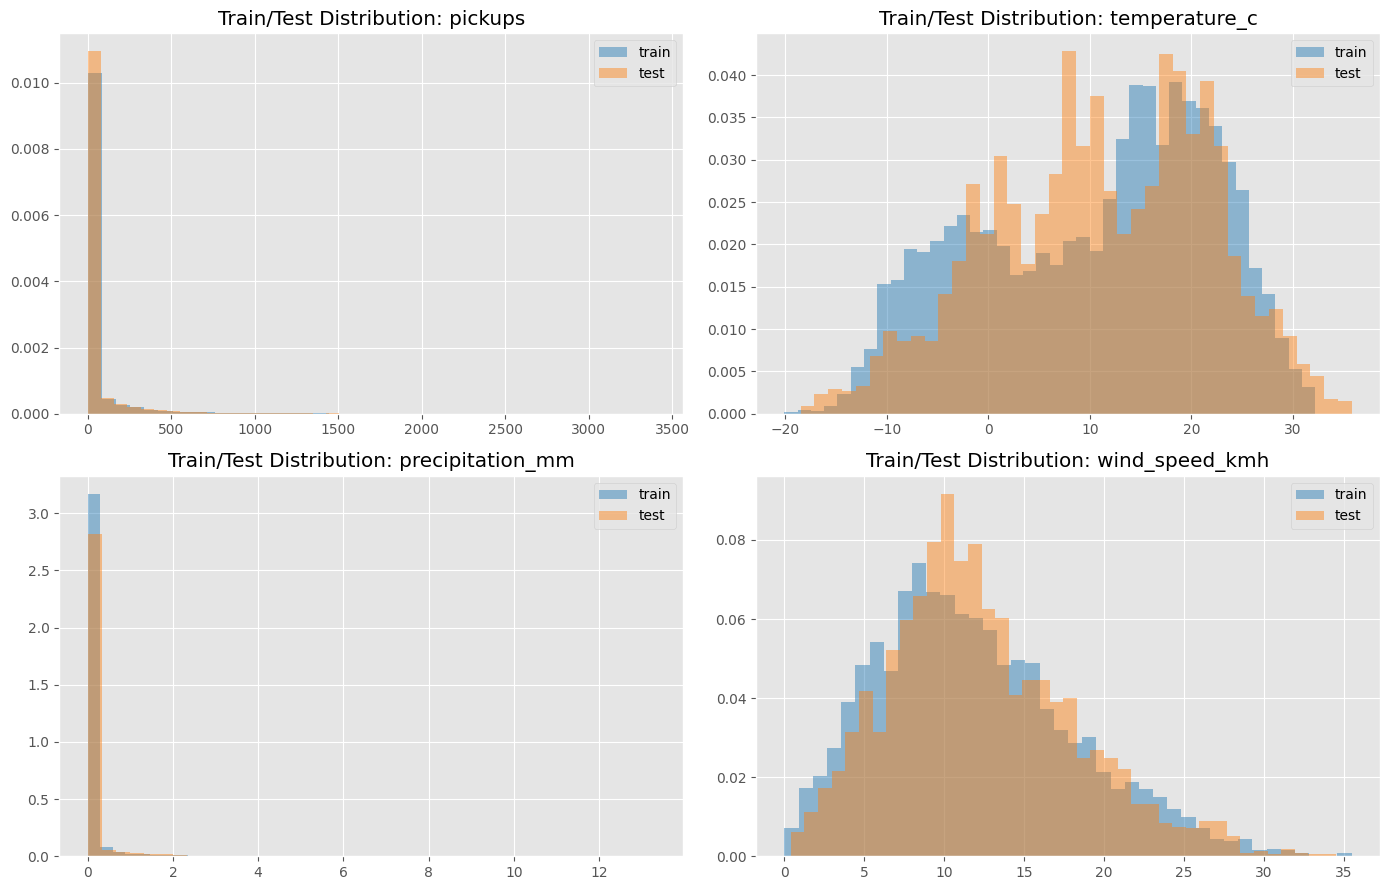

In [8]:
# Train vs test drift checks for key numeric columns
numeric_compare_cols = [
    "pickups", "temperature_c", "precipitation_mm", "wind_speed_kmh",
    "lag_1h", "lag_24h", "lag_168h", "rolling_24h_mean", "rolling_168h_mean"
]
numeric_compare_cols = [c for c in numeric_compare_cols if c in full.columns]

for col in numeric_compare_cols:
    summary = full.groupby("split")[col].describe()[["mean", "std", "min", "50%", "max"]]
    print(f"\n{col} summary by split:")
    display(summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_cols = numeric_compare_cols[:4]

for ax, col in zip(axes.flatten(), plot_cols):
    train_vals = full.loc[full["split"] == "train", col].dropna()
    test_vals = full.loc[full["split"] == "test", col].dropna()

    bins = 40
    ax.hist(train_vals, bins=bins, density=True, alpha=0.45, label="train", color="#1f77b4")
    ax.hist(test_vals, bins=bins, density=True, alpha=0.45, label="test", color="#ff7f0e")
    ax.set_title(f"Train/Test Distribution: {col}")
    ax.legend()

for ax in axes.flatten()[len(plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Baseline Modeling: Linear Regression

This section establishes reproducible baseline models before trying tree-based methods (Random Forest, XGBoost).
It trains a linear regression baseline on the processed train/test split and compares it with a simple naive baseline.

In [9]:
# Prepare baseline features and metrics helpers

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "sMAPE_pct": smape,
    }

if "train" not in globals() or "test" not in globals():
    train = pd.read_csv(PROCESSED_DIR / "train.csv", parse_dates=["hour"])
    test = pd.read_csv(PROCESSED_DIR / "test.csv", parse_dates=["hour"])

exclude_cols = {"pickups", "hour", "split"}
baseline_feature_cols = [
    c for c in train.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(train[c])
]

X_train = train[baseline_feature_cols].copy()
X_test = test[baseline_feature_cols].copy()
y_train = train["pickups"].astype(float).copy()
y_test = test["pickups"].astype(float).copy()

print(f"Baseline features ({len(baseline_feature_cols)}): {baseline_feature_cols}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Baseline features (19): ['cluster_id', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'cluster_capacity', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'is_holiday', 'is_rainy', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_24h_mean', 'rolling_168h_mean', 'cluster_avg_pickups']
X_train shape: (72000, 19)
X_test shape:  (37440, 19)


In [10]:
# Baseline 1: Linear regression (ordinary least squares via pseudoinverse)
X_train_mat = np.c_[np.ones(len(X_train)), X_train.values]
X_test_mat = np.c_[np.ones(len(X_test)), X_test.values]

beta = np.linalg.pinv(X_train_mat) @ y_train.values
train_pred_lr = X_train_mat @ beta
test_pred_lr = X_test_mat @ beta

# Pickups cannot be negative; clip for practical forecasting baseline
train_pred_lr = np.clip(train_pred_lr, 0, None)
test_pred_lr = np.clip(test_pred_lr, 0, None)

lr_train_metrics = regression_metrics(y_train, train_pred_lr)
lr_test_metrics = regression_metrics(y_test, test_pred_lr)

lr_metrics_df = pd.DataFrame([
    {"model": "linear_regression", "split": "train", **lr_train_metrics},
    {"model": "linear_regression", "split": "test", **lr_test_metrics},
])

print("Linear regression baseline metrics:")
display(lr_metrics_df)

Linear regression baseline metrics:


,model,split,MAE,RMSE,R2,sMAPE_pct
0,linear_regression,train,13.167033,43.360371,0.953137,78.687559
1,linear_regression,test,13.667923,44.481310,0.949699,81.687792


Test baseline comparison:


,model,split,MAE,RMSE,R2,sMAPE_pct
1,linear_regression,test,13.667923,44.481310,0.949699,81.687792
0,naive_lag_1h,test,20.105582,72.541404,0.866220,59.600404


Saved metrics: c:\Users\serverpc\Desktop\School Github Projects\ML Proj\processed\baseline_metrics.csv
Saved predictions: c:\Users\serverpc\Desktop\School Github Projects\ML Proj\processed\baseline_predictions.csv


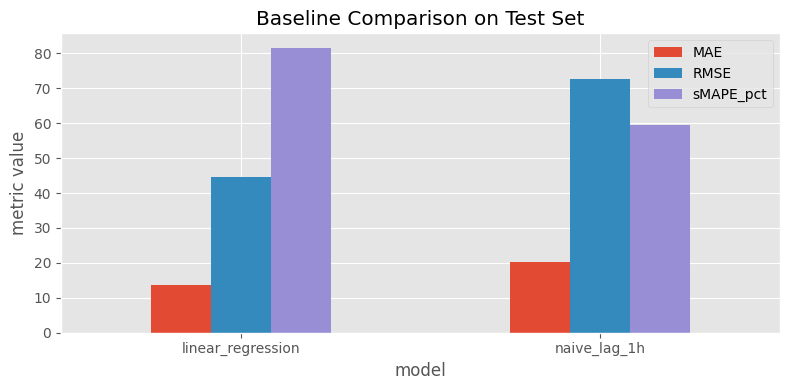

In [11]:
# Baseline 2: Naive comparator and output artifacts
if "lag_1h" in test.columns:
    test_pred_naive = test["lag_1h"].astype(float).values
else:
    test_pred_naive = np.full(len(test), y_train.mean(), dtype=float)

test_pred_naive = np.clip(test_pred_naive, 0, None)
naive_test_metrics = regression_metrics(y_test, test_pred_naive)

baseline_compare_df = pd.DataFrame([
    {"model": "naive_lag_1h", "split": "test", **naive_test_metrics},
    {"model": "linear_regression", "split": "test", **lr_test_metrics},
]).sort_values("RMSE")

print("Test baseline comparison:")
display(baseline_compare_df)

baseline_predictions = test[["cluster_id", "hour", "pickups"]].copy()
baseline_predictions["pred_naive"] = test_pred_naive
baseline_predictions["pred_linear_regression"] = test_pred_lr

metrics_path = PROCESSED_DIR / "baseline_metrics.csv"
preds_path = PROCESSED_DIR / "baseline_predictions.csv"
baseline_compare_df.to_csv(metrics_path, index=False)
baseline_predictions.to_csv(preds_path, index=False)

print(f"Saved metrics: {metrics_path}")
print(f"Saved predictions: {preds_path}")

# Quick visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = baseline_compare_df.set_index("model")[["MAE", "RMSE", "sMAPE_pct"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Baseline Comparison on Test Set")
ax.set_ylabel("metric value")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()